# ResNet50 Glaucoma Detection Using ACRIMA Fundus Images

**Research project:** Comparative Analysis of Deep Learning Architectures for Glaucoma Detection Using Retinal Fundus Images  
**Current architecture:** ResNet50 only  
**Task:** Binary classification using `Images_Cropped` from the ACRIMA dataset

This notebook is written to be executable from top to bottom in Google Colab with a GPU runtime. It builds a clean TensorFlow/Keras transfer-learning pipeline, evaluates the model with biomedical classification metrics, and saves the trained model for later comparison with other architectures.

## Requirements

- Python 3.10+
- TensorFlow 2.x
- NumPy
- Pandas
- Matplotlib
- Seaborn
- Scikit-learn
- Pillow

## 1. Imports

The libraries below cover dataset handling, image validation, TensorFlow model training, metric calculation, plotting, and model-size measurement.

In [1]:
import json
import os
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf

from PIL import Image, ImageFile
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras import layers, models, callbacks, optimizers
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

ImageFile.LOAD_TRUNCATED_IMAGES = True

print('TensorFlow version:', tf.__version__)
print('GPU devices:', tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Dataset Preparation From `index.json`

Only `train/Images_Cropped` is used for this classification experiment because your `val/index.json` and `test/index.json` files list image metadata but do not expose glaucoma/normal labels. Segmentation masks are intentionally ignored at this stage.

The parser below reads `ImgName` from `train/index.json` and derives binary labels from the REFUGE training image naming convention:

- filenames beginning with `g` are treated as `Glaucoma`
- filenames beginning with `n` are treated as `Normal`

The final dataframe contains exactly two important columns:

- `image_path`: full path to the cropped fundus image
- `label`: binary label where `1 = Glaucoma` and `0 = Normal`

In [ ]:
from pathlib import Path

ACRIMA_ROOT = Path("../dataset")
ACRIMA_IMAGES_DIR = ACRIMA_ROOT / "Images"

IMG_SIZE = (224, 224)  # ResNet50 standard ImageNet input size
BATCH_SIZE = 32
EPOCHS = 30
SEED = 42
OUTPUT_DIR = Path("../results/resnet50")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

assert ACRIMA_ROOT.exists(), f'ACRIMA root not found: {ACRIMA_ROOT}'
assert ACRIMA_IMAGES_DIR.exists(), f'Images folder not found: {ACRIMA_IMAGES_DIR}'

print('ACRIMA root:', ACRIMA_ROOT)
print('Images folder:', ACRIMA_IMAGES_DIR)
print('Output directory:', OUTPUT_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
ACRIMA root: /content/drive/MyDrive/ACRIMA/Database
Images folder: /content/drive/MyDrive/ACRIMA/Database/Images
Output directory: /content/resnet50_acrima_outputs


## Dataset

This project uses the **ACRIMA retinal fundus dataset**.

The dataset is **not included** in this repository because of licensing and distribution restrictions.

After downloading the dataset, place it in:

```
dataset/
└── Images/
```

In [4]:
image_files = []
for ext in ['*.jpg', '*.jpeg', '*.png', '*.bmp', '*.tif', '*.tiff']:
    image_files.extend(ACRIMA_IMAGES_DIR.glob(ext))
    image_files.extend(ACRIMA_IMAGES_DIR.glob(ext.upper()))

rows = []

for image_path in image_files:
    filename = image_path.name.lower()

    label = 1 if '_g_' in filename else 0
    class_name = 'Glaucoma' if label == 1 else 'Normal'

    rows.append({
        'image_path': str(image_path),
        'image_name': image_path.name,
        'label': label,
        'class_name': class_name
    })

df = pd.DataFrame(rows).sort_values('image_name').reset_index(drop=True)

print('Total images:', len(df))
print(df['class_name'].value_counts())
display(df.head())
display(df.tail())

Total images: 705
class_name
Glaucoma    396
Normal      309
Name: count, dtype: int64


,image_path,image_name,label,class_name
0,/content/drive/MyDrive/ACRIMA/Database/Images/...,Im001_ACRIMA.jpg,0,Normal
1,/content/drive/MyDrive/ACRIMA/Database/Images/...,Im002_ACRIMA.jpg,0,Normal
2,/content/drive/MyDrive/ACRIMA/Database/Images/...,Im003_ACRIMA.jpg,0,Normal
3,/content/drive/MyDrive/ACRIMA/Database/Images/...,Im004_ACRIMA.jpg,0,Normal
4,/content/drive/MyDrive/ACRIMA/Database/Images/...,Im005_ACRIMA.jpg,0,Normal


,image_path,image_name,label,class_name
700,/content/drive/MyDrive/ACRIMA/Database/Images/...,Im701_g_ACRIMA.jpg,1,Glaucoma
701,/content/drive/MyDrive/ACRIMA/Database/Images/...,Im702_g_ACRIMA.JPG,1,Glaucoma
702,/content/drive/MyDrive/ACRIMA/Database/Images/...,Im703_g_ACRIMA.JPG,1,Glaucoma
703,/content/drive/MyDrive/ACRIMA/Database/Images/...,Im704_g_ACRIMA.jpg,1,Glaucoma
704,/content/drive/MyDrive/ACRIMA/Database/Images/...,Im705_g_ACRIMA.jpg,1,Glaucoma


## 3. Image Validation and Corruption Handling

Medical image datasets can contain missing, partially downloaded, or unreadable files. This step verifies each image before training so corrupted samples do not crash the input pipeline.

In [5]:
df = df[df['image_path'].apply(lambda p: Path(p).exists())].reset_index(drop=True)

print('Images after path check:', len(df))
print(df['class_name'].value_counts())

Images after path check: 705
class_name
Glaucoma    396
Normal      309
Name: count, dtype: int64


## 4. Train, Validation, and Test Splits

A stratified split keeps the glaucoma/normal ratio similar across training, validation, and test sets. The test set is held back until final evaluation.

In [6]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df['label'],
    random_state=SEED,
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df['label'],
    random_state=SEED,
)

print('Train:', train_df.shape, train_df['class_name'].value_counts().to_dict())
print('Validation:', val_df.shape, val_df['class_name'].value_counts().to_dict())
print('Test:', test_df.shape, test_df['class_name'].value_counts().to_dict())

# REFUGE is highly imbalanced: most images are normal and fewer are glaucoma.
# Class weighting gives glaucoma samples more influence during training, which is important for screening sensitivity.
classes = np.array([0, 1])
computed_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=train_df['label'].values,
)
class_weight_dict = {int(class_id): float(weight) for class_id, weight in zip(classes, computed_weights)}
print('Class weights:', class_weight_dict)

Train: (493, 4) {'Glaucoma': 277, 'Normal': 216}
Validation: (106, 4) {'Glaucoma': 60, 'Normal': 46}
Test: (106, 4) {'Glaucoma': 59, 'Normal': 47}
Class weights: {0: 1.1412037037037037, 1: 0.8898916967509025}


## 5. Preprocessing Pipeline

Preprocessing matters because ResNet50 was originally trained on ImageNet images with a specific input format. Each retinal image is decoded as RGB, resized to `224 x 224`, and normalized with `preprocess_input` so the input distribution is compatible with the pretrained backbone.

In [7]:
def load_and_preprocess_image(image_path, label):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)
    image = preprocess_input(image)
    return image, tf.cast(label, tf.float32)

def make_dataset(dataframe, shuffle=False, augment=False):
    paths = dataframe['image_path'].values
    labels = dataframe['label'].values.astype(np.float32)

    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(dataframe), seed=SEED, reshuffle_each_iteration=True)

    dataset = dataset.map(load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
    if augment:
        dataset = dataset.map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=tf.data.AUTOTUNE)

    dataset = dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return dataset

## 6. Data Augmentation

Augmentation helps reduce overfitting by exposing the model to realistic variations in retinal images. Small rotations, horizontal flips, zoom changes, and brightness shifts can make the model less dependent on exact image positioning or illumination.

In [8]:
class RandomBrightness(layers.Layer):
    def __init__(self, max_delta=0.12, **kwargs):
        super().__init__(**kwargs)
        self.max_delta = max_delta

    def call(self, inputs, training=None):
        if training:
            return tf.image.random_brightness(inputs, max_delta=self.max_delta)
        return inputs

    def get_config(self):
        config = super().get_config()
        config.update({'max_delta': self.max_delta})
        return config

data_augmentation = tf.keras.Sequential(
    [
        layers.RandomRotation(0.08, seed=SEED),
        layers.RandomFlip('horizontal', seed=SEED),
        layers.RandomZoom(height_factor=0.10, width_factor=0.10, seed=SEED),
        RandomBrightness(max_delta=0.12),
    ],
    name='data_augmentation',
)

train_ds = make_dataset(train_df, shuffle=True, augment=True)
val_ds = make_dataset(val_df, shuffle=False, augment=False)
test_ds = make_dataset(test_df, shuffle=False, augment=False)

for images, labels in train_ds.take(1):
    print('Batch image shape:', images.shape)
    print('Batch label shape:', labels.shape)

Batch image shape: (32, 224, 224, 3)
Batch label shape: (32,)


## 7. Build ResNet50 Transfer Learning Model

Transfer learning is used because biomedical datasets are often smaller than large natural-image datasets. A ResNet50 model pretrained on ImageNet already knows useful low-level visual features such as edges, textures, curves, and color contrasts. ResNet50 is suitable because residual connections allow a deeper network to train reliably, and it is widely used as a strong baseline for medical image classification.

Overfitting is controlled using data augmentation, dropout, early stopping, learning-rate reduction, and by freezing the pretrained ResNet50 backbone during the first training stage.

In [ ]:
def build_resnet50_model(input_shape=(224, 224, 3), dropout_rate=0.40):
    base_model = ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape,
    )

    # Freeze the pretrained backbone first so the custom classifier learns without destroying useful ImageNet features.
    base_model.trainable = False

    inputs = layers.Input(shape=input_shape, name='fundus_image')
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D(name='global_average_pooling')(x)
    x = layers.BatchNormalization(name='batch_norm')(x)
    x = layers.Dense(256, activation='relu', name='dense_256')(x)
    x = layers.Dropout(dropout_rate, name='dropout')(x)
    outputs = layers.Dense(1, activation='sigmoid', name='glaucoma_probability')(x)

    model = models.Model(
    inputs=inputs,
    outputs=outputs,
    name='ResNet50_ACRIMA_Glaucoma'
)
    return model, base_model

model, base_model = build_resnet50_model(input_shape=IMG_SIZE + (3,))

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy'],
)

model.summary()

Model: "ResNet50_REFUGE_Glaucoma"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ fundus_image (InputLayer)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm (BatchNormalization) │ (None, 2048)           │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_256 (Dense)               │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ glaucoma_probability (Dense)    │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,120,705 (92.01 MB)

 Trainable params: 528,897 (2.02 MB)

 Non-trainable params: 23,591,808 (90.00 MB)

## 8. Training

The callbacks monitor validation loss. `EarlyStopping` prevents unnecessary training after validation performance stops improving, `ModelCheckpoint` saves the best model, and `ReduceLROnPlateau` lowers the learning rate when progress slows.

In [10]:
best_model_path = OUTPUT_DIR / 'best_resnet50_glaucoma.keras'

training_callbacks = [
    callbacks.EarlyStopping(
        monitor='val_loss',
        patience=7,
        restore_best_weights=True,
        verbose=1,
    ),
    callbacks.ModelCheckpoint(
        filepath=str(best_model_path),
        monitor='val_loss',
        save_best_only=True,
        verbose=1,
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=3,
        min_lr=1e-7,
        verbose=1,
    ),
]

start_time = time.time()
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=training_callbacks,
    class_weight=class_weight_dict,
)
training_time_seconds = time.time() - start_time

print(f'Training time: {training_time_seconds:.2f} seconds ({training_time_seconds / 60:.2f} minutes)')

Epoch 1/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 820ms/step - accuracy: 0.5670 - loss: 0.7411
Epoch 1: val_loss improved from None to 0.50551, saving model to /content/resnet50_acrima_outputs/best_resnet50_glaucoma.keras

Epoch 1: finished saving model to /content/resnet50_acrima_outputs/best_resnet50_glaucoma.keras
16/16 ━━━━━━━━━━━━━━━━━━━━ 45s 2s/step - accuracy: 0.6430 - loss: 0.6478 - val_accuracy: 0.7736 - val_loss: 0.5055 - learning_rate: 1.0000e-04
Epoch 2/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 538ms/step - accuracy: 0.8183 - loss: 0.3984
Epoch 2: val_loss improved from 0.50551 to 0.39878, saving model to /content/resnet50_acrima_outputs/best_resnet50_glaucoma.keras

Epoch 2: finished saving model to /content/resnet50_acrima_outputs/best_resnet50_glaucoma.keras
16/16 ━━━━━━━━━━━━━━━━━━━━ 12s 732ms/step - accuracy: 0.8114 - loss: 0.4047 - val_accuracy: 0.8679 - val_loss: 0.3988 - learning_rate: 1.0000e-04
Epoch 3/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 519ms/step - accuracy: 0.8737 - loss: 0.3000
Ep

## 9. Training Curves
Accuracy and loss curves help diagnose overfitting. A large gap between training and validation performance usually means the model is memorizing training data instead of generalizing.

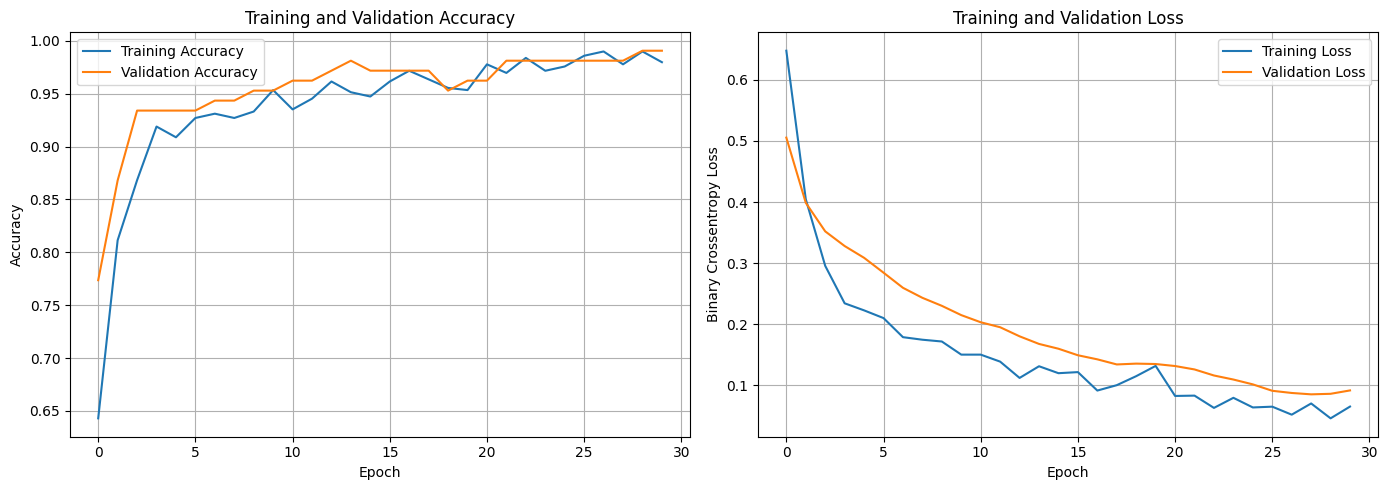

In [11]:
def plot_training_history(history):
    history_df = pd.DataFrame(history.history)

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history_df['accuracy'], label='Training Accuracy')
    plt.plot(history_df['val_accuracy'], label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(history_df['loss'], label='Training Loss')
    plt.plot(history_df['val_loss'], label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Binary Crossentropy Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

plot_training_history(history)

## 10. Validation Threshold Tuning

A fixed `0.5` probability threshold is simple, but glaucoma screening often benefits from a threshold chosen to improve recall. This section chooses a threshold on the validation set before the test set is evaluated. The test set remains untouched until the next section.

In [12]:
val_true = val_df['label'].values.astype(int)
val_prob = model.predict(val_ds).ravel()

threshold_rows = []
for threshold in np.arange(0.10, 0.91, 0.01):
    val_pred = (val_prob >= threshold).astype(int)
    threshold_rows.append(
        {
            'threshold': threshold,
            'precision': precision_score(val_true, val_pred, zero_division=0),
            'recall': recall_score(val_true, val_pred, zero_division=0),
            'f1': f1_score(val_true, val_pred, zero_division=0),
        }
    )

threshold_df = pd.DataFrame(threshold_rows)

# Prefer high glaucoma recall while keeping precision reasonable.
# If no threshold reaches the precision floor, fall back to the best F1-score.
precision_floor = 0.50
eligible_thresholds = threshold_df[threshold_df['precision'] >= precision_floor]
if not eligible_thresholds.empty:
    best_row = eligible_thresholds.sort_values(
        ['recall', 'f1', 'precision'], ascending=False
    ).iloc[0]
else:
    best_row = threshold_df.sort_values(['f1', 'recall'], ascending=False).iloc[0]

SELECTED_THRESHOLD = float(best_row['threshold'])

display(threshold_df.sort_values(['recall', 'f1', 'precision'], ascending=False).head(10))
print(f'Selected threshold: {SELECTED_THRESHOLD:.2f}')
print(f"Validation precision at selected threshold: {best_row['precision']:.4f}")
print(f"Validation recall at selected threshold: {best_row['recall']:.4f}")
print(f"Validation F1-score at selected threshold: {best_row['f1']:.4f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step


,threshold,precision,recall,f1
22,0.32,0.967742,1.0,0.983607
23,0.33,0.967742,1.0,0.983607
24,0.34,0.967742,1.0,0.983607
25,0.35,0.967742,1.0,0.983607
26,0.36,0.967742,1.0,0.983607
27,0.37,0.967742,1.0,0.983607
28,0.38,0.967742,1.0,0.983607
29,0.39,0.967742,1.0,0.983607
30,0.40,0.967742,1.0,0.983607
31,0.41,0.967742,1.0,0.983607


Selected threshold: 0.32
Validation precision at selected threshold: 0.9677
Validation recall at selected threshold: 1.0000
Validation F1-score at selected threshold: 0.9836


## 11. Test Evaluation

The test set is evaluated only after training is complete and after the threshold is selected from validation data. For biomedical AI, accuracy alone is not enough, so precision, recall, F1-score, confusion matrix, ROC curve, and ROC-AUC are reported.

In [13]:
y_true = test_df['label'].values.astype(int)

test_start = time.time()
y_prob = model.predict(test_ds).ravel()
total_inference_time = time.time() - test_start

y_pred = (y_prob >= SELECTED_THRESHOLD).astype(int)
inference_time_per_image = total_inference_time / len(test_df)

test_accuracy = accuracy_score(y_true, y_pred)
test_precision = precision_score(y_true, y_pred, zero_division=0)
test_recall = recall_score(y_true, y_pred, zero_division=0)
test_f1 = f1_score(y_true, y_pred, zero_division=0)
test_auc = roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) == 2 else np.nan

print(f'Selected threshold: {SELECTED_THRESHOLD:.2f}')
print(f'Test Accuracy:  {test_accuracy:.4f}')
print(f'Test Precision: {test_precision:.4f}')
print(f'Test Recall:    {test_recall:.4f}')
print(f'Test F1-score:  {test_f1:.4f}')
print(f'ROC-AUC Score:  {test_auc:.4f}')
print(f'Inference time per image: {inference_time_per_image:.6f} seconds')

print('\nClassification Report:')
print(classification_report(y_true, y_pred, target_names=['Normal', 'Glaucoma'], zero_division=0))

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 127ms/step
Selected threshold: 0.32
Test Accuracy:  0.9057
Test Precision: 0.9016
Test Recall:    0.9322
Test F1-score:  0.9167
ROC-AUC Score:  0.9650
Inference time per image: 0.006576 seconds

Classification Report:
              precision    recall  f1-score   support

      Normal       0.91      0.87      0.89        47
    Glaucoma       0.90      0.93      0.92        59

    accuracy                           0.91       106
   macro avg       0.91      0.90      0.90       106
weighted avg       0.91      0.91      0.91       106



## 12. Confusion Matrix Heatmap

The confusion matrix shows correct and incorrect predictions for each class. In glaucoma screening, false negatives are especially important because missed glaucoma cases may delay treatment.

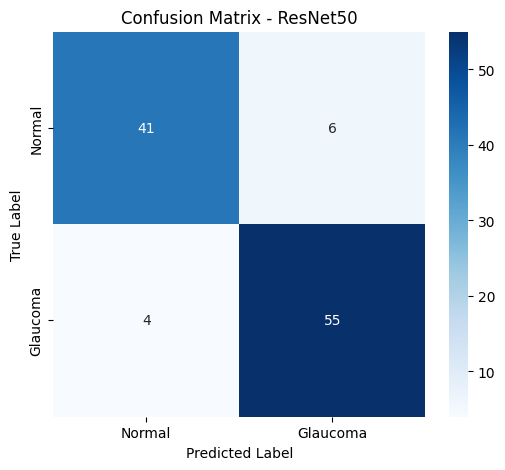

In [14]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Normal', 'Glaucoma'],
    yticklabels=['Normal', 'Glaucoma'],
)
plt.title('Confusion Matrix - ResNet50')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## 13. ROC Curve

The ROC curve shows the trade-off between sensitivity and false-positive rate at different probability thresholds. ROC-AUC summarizes this behavior in a single score.

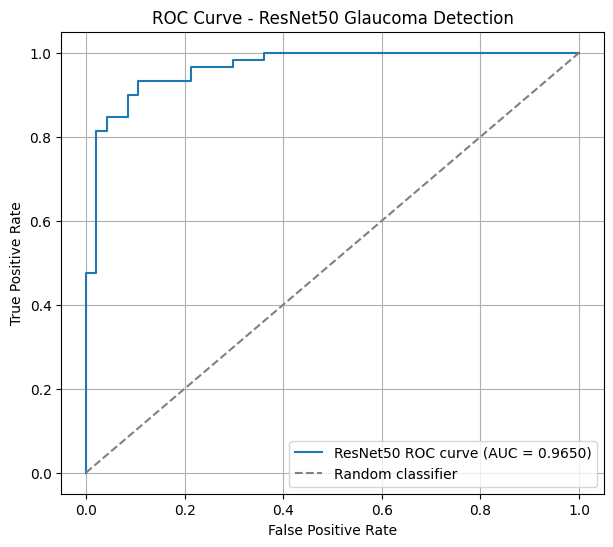

In [15]:
if len(np.unique(y_true)) == 2:
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)

    plt.figure(figsize=(7, 6))
    plt.plot(fpr, tpr, label=f'ResNet50 ROC curve (AUC = {test_auc:.4f})')
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random classifier')
    plt.title('ROC Curve - ResNet50 Glaucoma Detection')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()
else:
    print('ROC curve cannot be plotted because the test set contains only one class.')

## 14. Save the Trained Model

The model is saved in two formats:

- `.h5`: common Keras format used in many student projects
- TensorFlow SavedModel: useful for deployment workflows and later conversion to TensorFlow Lite

In [16]:
h5_model_path = OUTPUT_DIR / 'resnet50_glaucoma_model.h5'
saved_model_path = OUTPUT_DIR / 'resnet50_glaucoma_saved_model'

model.save(str(h5_model_path))

# Keras 3 uses model.export() for TensorFlow SavedModel. Older Keras versions use model.save(directory).
try:
    model.export(str(saved_model_path))
except AttributeError:
    model.save(str(saved_model_path))

h5_size_mb = h5_model_path.stat().st_size / (1024 * 1024)
saved_model_size_mb = sum(p.stat().st_size for p in saved_model_path.rglob('*') if p.is_file()) / (1024 * 1024)

print('Saved H5 model:', h5_model_path)
print('SavedModel directory:', saved_model_path)
print(f'H5 model size: {h5_size_mb:.2f} MB')
print(f'SavedModel size: {saved_model_size_mb:.2f} MB')

Saved artifact at '/content/resnet50_acrima_outputs/resnet50_glaucoma_saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='fundus_image')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  132947725448784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132947725449552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132947725450128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132947725450320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132947725448400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132947725448592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132947599968016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132947599967824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132947599968976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132947599969168: TensorSpec(shape=(), 

## 15. Random Test Prediction

This section loads one random retinal fundus image from the test set, preprocesses it exactly like the training pipeline, runs inference, displays the image, and prints the predicted class with confidence.

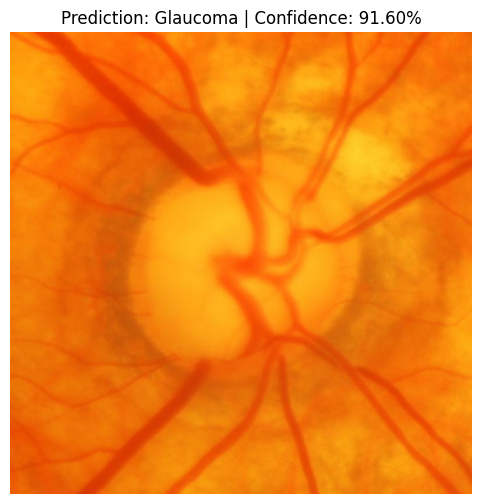

Image path: /content/drive/MyDrive/ACRIMA/Database/Images/Im322_g_ACRIMA.jpg
True label: Glaucoma
Predicted label: Glaucoma
Glaucoma probability: 0.9160
Prediction confidence: 91.60%
Single-image inference time: 0.105559 seconds


In [22]:
def preprocess_single_image(image_path):
    image = Image.open(image_path).convert('RGB')
    display_image = image.copy()
    image = image.resize(IMG_SIZE)
    image_array = np.array(image).astype(np.float32)
    image_array = preprocess_input(image_array)
    image_array = np.expand_dims(image_array, axis=0)
    return image_array, display_image

sample_row = test_df.sample(1, random_state=random.randint(0, 10_000)).iloc[0]
sample_path = sample_row['image_path']
sample_true_label = sample_row['class_name']

sample_array, sample_display = preprocess_single_image(sample_path)

prediction_start = time.time()
sample_probability = float(model.predict(sample_array, verbose=0)[0][0])
single_image_inference_time = time.time() - prediction_start

predicted_label = 'Glaucoma' if sample_probability >= 0.5 else 'Normal'
confidence = sample_probability if predicted_label == 'Glaucoma' else 1.0 - sample_probability

plt.figure(figsize=(6, 6))
plt.imshow(sample_display)
plt.axis('off')
plt.title(f'Prediction: {predicted_label} | Confidence: {confidence:.2%}')
plt.show()

print('Image path:', sample_path)
print('True label:', sample_true_label)
print('Predicted label:', predicted_label)
print(f'Glaucoma probability: {sample_probability:.4f}')
print(f'Prediction confidence: {confidence:.2%}')
print(f'Single-image inference time: {single_image_inference_time:.6f} seconds')

## 16. Experiment Summary

Run this cell after training and evaluation to produce a compact research-style summary for your report.

In [18]:
summary = {
    'Architecture': 'ResNet50 transfer learning',
    'Dataset': 'ACRIMA optic-disc cropped fundus images',
    'Train images': len(train_df),
    'Validation images': len(val_df),
    'Test images': len(test_df),
    'Test accuracy': round(test_accuracy, 4),
    'Test precision': round(test_precision, 4),
    'Test recall': round(test_recall, 4),
    'Test F1-score': round(test_f1, 4),
    'ROC-AUC': round(float(test_auc), 4) if not np.isnan(test_auc) else 'Not available',
    'Training time seconds': round(training_time_seconds, 2),
    'Inference time per image seconds': round(inference_time_per_image, 6),
    'H5 model size MB': round(h5_size_mb, 2),
    'SavedModel size MB': round(saved_model_size_mb, 2),
}

display(pd.DataFrame([summary]))

print('Performance summary:')
print(f"The ResNet50 model achieved {test_accuracy:.4f} accuracy, {test_precision:.4f} precision, {test_recall:.4f} recall, {test_f1:.4f} F1-score, and {test_auc:.4f} ROC-AUC on the held-out test set.")

print('\nLimitations:')
print('- The model uses only cropped fundus images and does not yet use optic-disc masks or segmentation information.')
print('- Performance depends strongly on dataset quality, split strategy, class imbalance, and external validation.')
print('- A single dataset test split is not enough for clinical deployment claims.')

print('\nPossible future improvements:')
print('- Compare ResNet50 with EfficientNet, DenseNet, VGG, MobileNet, and Vision Transformer baselines.')
print('- Add fine-tuning by unfreezing the last ResNet50 blocks with a very small learning rate.')
print('- Use class weighting, threshold tuning, cross-validation, and external datasets for stronger validation.')
print('- Explore segmentation-guided classification using optic disc/cup masks later.')

print('\nRaspberry Pi deployment suitability:')
print('- ResNet50 is a strong research baseline but may be heavy for Raspberry Pi inference.')
print('- For future edge deployment, convert to TensorFlow Lite and test quantization.')
print('- A lighter model such as MobileNetV2/EfficientNet-Lite may be more practical for real-time Raspberry Pi use.')

,Architecture,Dataset,Train images,Validation images,Test images,Test accuracy,Test precision,Test recall,Test F1-score,ROC-AUC,Training time seconds,Inference time per image seconds,H5 model size MB,SavedModel size MB
0,ResNet50 transfer learning,ACRIMA optic-disc cropped fundus images,493,106,106,0.9057,0.9016,0.9322,0.9167,0.965,434.52,0.006576,96.44,186.19


Performance summary:
The ResNet50 model achieved 0.9057 accuracy, 0.9016 precision, 0.9322 recall, 0.9167 F1-score, and 0.9650 ROC-AUC on the held-out test set.

Limitations:
- The model uses only cropped fundus images and does not yet use optic-disc masks or segmentation information.
- Performance depends strongly on dataset quality, split strategy, class imbalance, and external validation.
- A single dataset test split is not enough for clinical deployment claims.

Possible future improvements:
- Compare ResNet50 with EfficientNet, DenseNet, VGG, MobileNet, and Vision Transformer baselines.
- Add fine-tuning by unfreezing the last ResNet50 blocks with a very small learning rate.
- Use class weighting, threshold tuning, cross-validation, and external datasets for stronger validation.
- Explore segmentation-guided classification using optic disc/cup masks later.

Raspberry Pi deployment suitability:
- ResNet50 is a strong research baseline but may be heavy for Raspberry Pi inference.
-

## 17. Five-Fold Stratified Cross-Validation

In [19]:
from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight

N_SPLITS = 5
CV_EPOCHS = 20
cv_results = []

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

for fold, (trainval_idx, test_idx) in enumerate(skf.split(df, df['label']), start=1):
    print(f'\n========== Fold {fold}/{N_SPLITS} ==========')

    trainval_df = df.iloc[trainval_idx].reset_index(drop=True)
    fold_test_df = df.iloc[test_idx].reset_index(drop=True)

    fold_train_df, fold_val_df = train_test_split(
        trainval_df,
        test_size=0.15,
        stratify=trainval_df['label'],
        random_state=SEED + fold
    )

    fold_train_ds = make_dataset(fold_train_df, shuffle=True, augment=True)
    fold_val_ds = make_dataset(fold_val_df, shuffle=False, augment=False)
    fold_test_ds = make_dataset(fold_test_df, shuffle=False, augment=False)

    fold_model, _ = build_resnet50_model(input_shape=IMG_SIZE + (3,))
    fold_model.compile(
        optimizer=optimizers.Adam(learning_rate=1e-4),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    fold_callbacks = [
        callbacks.EarlyStopping(
            monitor='val_loss',
            patience=5,
            restore_best_weights=True,
            verbose=1
        ),
        callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.3,
            patience=2,
            min_lr=1e-7,
            verbose=1
        )
    ]

    start_time = time.time()

    fold_model.fit(
        fold_train_ds,
        validation_data=fold_val_ds,
        epochs=CV_EPOCHS,
        callbacks=fold_callbacks,
        verbose=1
    )

    training_time = time.time() - start_time

    y_true_fold = fold_test_df['label'].values.astype(int)
    y_prob_fold = fold_model.predict(fold_test_ds).ravel()
    y_pred_fold = (y_prob_fold >= 0.5).astype(int)

    fold_accuracy = accuracy_score(y_true_fold, y_pred_fold)
    fold_precision = precision_score(y_true_fold, y_pred_fold, zero_division=0)
    fold_recall = recall_score(y_true_fold, y_pred_fold, zero_division=0)
    fold_f1 = f1_score(y_true_fold, y_pred_fold, zero_division=0)
    fold_auc = roc_auc_score(y_true_fold, y_prob_fold)

    cv_results.append({
        'fold': fold,
        'accuracy': fold_accuracy,
        'precision': fold_precision,
        'recall_sensitivity': fold_recall,
        'f1_score': fold_f1,
        'roc_auc': fold_auc,
        'training_time_seconds': training_time,
        'test_normal_count': int((y_true_fold == 0).sum()),
        'test_glaucoma_count': int((y_true_fold == 1).sum())
    })

    print(classification_report(
        y_true_fold,
        y_pred_fold,
        target_names=['Normal', 'Glaucoma'],
        zero_division=0
    ))


========== Fold 1/5 ==========
Epoch 1/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.6075 - loss: 0.7247 - val_accuracy: 0.7294 - val_loss: 0.5375 - learning_rate: 1.0000e-04
Epoch 2/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 11s 757ms/step - accuracy: 0.8288 - loss: 0.3918 - val_accuracy: 0.8353 - val_loss: 0.4222 - learning_rate: 1.0000e-04
Epoch 3/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 19s 648ms/step - accuracy: 0.8518 - loss: 0.3285 - val_accuracy: 0.8588 - val_loss: 0.3625 - learning_rate: 1.0000e-04
Epoch 4/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 11s 755ms/step - accuracy: 0.8706 - loss: 0.2939 - val_accuracy: 0.8824 - val_loss: 0.3282 - learning_rate: 1.0000e-04
Epoch 5/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 11s 707ms/step - accuracy: 0.8914 - loss: 0.2876 - val_accuracy: 0.8706 - val_loss: 0.3030 - learning_rate: 1.0000e-04
Epoch 6/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 10s 614ms/step - accuracy: 0.9123 - loss: 0.2232 - val_accuracy: 0.8824 - val_loss: 0.2872 - learning_rate: 1.0000e-04
Epoch 7/20
15/15 ━━━━━━━━━━━━

4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step 

5/5 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step
              precision    recall  f1-score   support

      Normal       0.94      0.95      0.94        62
    Glaucoma       0.96      0.95      0.96        79

    accuracy                           0.95       141
   macro avg       0.95      0.95      0.95       141
weighted avg       0.95      0.95      0.95       141


========== Fold 3/5 ==========
Epoch 1/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 39s 2s/step - accuracy: 0.7203 - loss: 0.5904 - val_accuracy: 0.8588 - val_loss: 0.4689 - learning_rate: 1.0000e-04
Epoch 2/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 11s 733ms/step - accuracy: 0.8455 - loss: 0.3687 - val_accuracy: 0.8824 - val_loss: 0.3933 - learning_rate: 1.0000e-04
Epoch 3/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 9s 596ms/step - accuracy: 0.8685 - loss: 0.3211 - val_accuracy: 0.8941 - val_loss: 0.3739 - learning_rate: 1.0000e-04
Epoch 4/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 12s 746ms/step - accuracy: 0.8998 - loss: 0.2756 - val_accuracy: 0.9059 - val_loss: 0.3376 - learni

In [20]:
cv_results_df = pd.DataFrame(cv_results)
display(cv_results_df)

summary_df = cv_results_df[
    ['accuracy', 'precision', 'recall_sensitivity', 'f1_score', 'roc_auc']
].agg(['mean', 'std'])

display(summary_df)

print('5-Fold Cross-Validation Summary')
print(f"Accuracy:    {cv_results_df['accuracy'].mean():.4f} ± {cv_results_df['accuracy'].std():.4f}")
print(f"Precision:   {cv_results_df['precision'].mean():.4f} ± {cv_results_df['precision'].std():.4f}")
print(f"Sensitivity: {cv_results_df['recall_sensitivity'].mean():.4f} ± {cv_results_df['recall_sensitivity'].std():.4f}")
print(f"F1-score:    {cv_results_df['f1_score'].mean():.4f} ± {cv_results_df['f1_score'].std():.4f}")
print(f"ROC-AUC:     {cv_results_df['roc_auc'].mean():.4f} ± {cv_results_df['roc_auc'].std():.4f}")

,fold,accuracy,precision,recall_sensitivity,f1_score,roc_auc,training_time_seconds,test_normal_count,test_glaucoma_count
0,1,0.950355,0.961538,0.949367,0.955414,0.989996,270.653491,62,79
1,2,0.950355,0.961538,0.949367,0.955414,0.985096,259.223624,62,79
2,3,0.936170,0.972973,0.911392,0.941176,0.982442,259.574820,62,79
3,4,0.929078,0.936709,0.936709,0.936709,0.972234,275.596082,62,79
4,5,0.943262,0.950000,0.950000,0.950000,0.979713,270.752153,61,80


,accuracy,precision,recall_sensitivity,f1_score,roc_auc
mean,0.941844,0.956552,0.939367,0.947743,0.981896
std,0.009247,0.013748,0.016604,0.008480,0.006601


5-Fold Cross-Validation Summary
Accuracy:    0.9418 ± 0.0092
Precision:   0.9566 ± 0.0137
Sensitivity: 0.9394 ± 0.0166
F1-score:    0.9477 ± 0.0085
ROC-AUC:     0.9819 ± 0.0066
